# Feature analysis — trade-flow imbalance

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`flow_imbalance` function in §3. The data loading, the checks, and the plots adapt on their own.

**The example** is `flow_imbalance`: of byb's recent trades, how much volume hit the ask
(aggressive buys) versus the bid (aggressive sells), netted and normalised. When buyers are
leaning on the offer, byb's mid tends to tick up next; when sellers are hitting the bid, down.
It is a textbook **price-head (direction)** feature, and we check the rate head too.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own. And they
are **marginal screens** — does the feature carry signal worth feeding — **not** measures of
distributional fit: the model's actual targets are the count distribution `P(K = k)` and the
count-conditioned price family `D_k` mixed above, fit downstream, not what these rank-ICs measure
(§7 inspects the realised count/return distributions by feature bucket).

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature (this one *is* poolable — a per-exchange number, not a gap *between*
  exchanges), first check per-exchange vs single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — this feature is an `E / W` *ratio* already in `[−1, 1]`, so it needs **no**
  vol/rate division. Dividing a bounded imbalance by `σ_ev` would *add* a regime dependence it
  doesn't have. (Contrast the template's price gap, which is bigger when volatile and so *must*
  be divided by `σ_ev`.)
- **Don't invent your own vol/rate scale.** When you *do* normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing it on real data.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — the flow legs,
  `σ_ev`, `λ_ev`, any rolling statistic — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event** (a trade on its own exchange — same-timestamp events as one update, never stale between trades), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update). For this flow, that relevant event is a trade of
  *its own* exchange: it injects that timestamp's summed mass. A value that ignores its own trades since the last clock
  read is **stale** — wrong, and a silent source of lag. The choice of EMA *and when it updates* is what makes
  the read well-behaved — pick both deliberately (see the "Choosing the EMA" section).
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: for the flow imbalance, a trade of *this* exchange; for `σ_ev`, a byb mid-move. A timestamp with only
  **irrelevant** trades injects nothing for that EMA, yet it still
  **ticks** (decays) once *iff* a trade lands, on the one **shared** trade clock
  (one tick per trade-timestamp across **all** venues, simultaneous prints counting once). Inject and
  decay are independent and neither ever fires more than once per timestamp, whatever the feature.
  Records sharing a timestamp are **one** sample, not a sequence: same-timestamp aggregation sets only
  that sample's **value** — never the number of samples, never the number of ticks. *What* value depends on the quantity: a **level**
  read takes the *last* state (mid, microprice); a **flow** **sums** the records at that timestamp
  (the imbalance sums its trades' `signed_qty` and `qty`). So a backed-up burst of N trade prints at one
  instant is still **one** weight-1 sample — value = the summed flow — **never** N
  samples. Injecting N silently overweights exactly the instants where a feed stalled and dumped a burst
  (N× weight on the `E/W` mean at one timestamp) and corrupts the count `W` that normalises it.
- **Do read a sparse flow as `E / W`.** A quantity present on only *some* events (here, byb's own
  trade flow — `σ_ev` is itself such an `E / W`) still needs the
  trade-tick EMA, but as **two** of them — the value `E` and its weight `W`, both decayed every
  trade-timestamp yet each pushed a sample only at the timestamps carrying its own events — read as the ratio `E / W`, which cancels the
  in-between decay and the warm-up bias. Dividing by `W` cancels the foreign-event decay exactly,
  so an `E / W` on the **combined** trade clock at span `N` approximates that exchange's **own**-clock
  EMA at a rescaled span — roughly `N` times that exchange's share of the combined trade rate — i.e. you get genuine per-exchange stats from the one shared clock. (That
  merged-clock ↔ own-clock equivalence — tight at large `N`, fraying at small `N` where the
  cross-venue lead/lag lives — is what `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but feed both the *signed* feature.** Check whether the
  signed feature predicts *direction* (price head) and whether its *magnitude* predicts
  *intensity* (rate head). Those checks are diagnostics — in the model, feed the **signed**
  feature to *both* heads, never a pre-computed `|feature|`. The rate head will learn the
  magnitude itself, *and* learn that buy pressure on one exchange can cancel sell pressure on another
  (or reinforce it). Pre-taking `|·|` per feature destroys the sign and that interaction.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** (the rate head sees the signed feature but can learn its magnitude) — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a mean trade size) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass (this imbalance is exactly such a bounded ratio), and even a ratio of two non-invariant levels can
  be invariant when they co-move. Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts over the **invariant**
  controls. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor, marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | of an exchange's recent trades, the share of volume that bought (lifted the ask) minus sold (hit the bid), netted and normalised — one number per time-scale |
| **feeds** | both heads — primarily *direction* (price head: which way byb moves); the rate head is checked too; both are fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** Tag each trade by who was aggressive: a buy that **lifts the ask** (via
`io._trade_lifts_ask`) carries `+qty`, a sell that **hits the bid** carries `−qty`. Call that
`signed_qty`. The feature is an exponentially-weighted **ratio**:

`feature(span) = EMA(signed_qty) / EMA(qty)`

— the recent trade flow's net direction as a fraction of its total volume, always in `[−1, 1]`.
`+1` means every recent unit of volume was an aggressive buy; `−1`, all aggressive sells; `0`,
balanced. Sweep `span` — short spans see the last few trades, long spans a longer history.

**Why it should work.** Aggressive order flow *is* the mechanism that moves price: a buyer who
keeps lifting the ask walks the book up, and the mid follows. Persistent one-sided flow
(autocorrelated by design — large orders are sliced and worked over many prints) signals that
pressure is ongoing, so it predicts the *direction* of byb's next move. This is order-flow
imbalance, one of the most studied microstructure predictors.

**Why a ratio (and no σ-division).** The imbalance is already dimensionless and bounded in
`[−1, 1]`: dividing `E` and `W` by the *same* trade-clock decay cancels both the decay and the
warm-up bias, and it is comparable across calm and wild markets **without** a volatility
yardstick. So — unlike the template's price gap — we do **not** divide it by `σ_ev`. (We still
build `σ_ev`, `λ_ev` below: the *target* is in σ-units, and they're the regime controls in §5.)

**What would disprove it.** No directional power at any span, or power that vanishes once we
account for how volatile / busy the market is (meaning it was only tracking regime).

> **No fixed leader.** This feature is a per-exchange number, so we build the same imbalance for
> **every** exchange's trades against byb's next move, and keep them all (§9 sweeps when
> per-exchange beats a single exchange).

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). The flow imbalance is a **sparse flow** — it
carries a value (`signed_qty`, `qty`) only on the *trades of its own exchange* — so it is the textbook case
for the self-normalising `E / W` read. Choose the EMA type and injection rule for the statistic being measured.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **sparse flow** — present on only *some* events (a per-exchange trade flow; byb's mid-moves): use
  **`KernelMeanEMA`**, the self-normalising `E / W`. `add(value, weight)` injects `E += α·value·weight`,
  `W += α·weight`; `value()` returns `E / W`. Feeding `add(sign, weight=qty)` — where `sign = +1` for an
  ask-lift and `−1` for a bid-hit — makes `E = EMA(signed_qty)` and `W = EMA(qty)`, so
  `value() = EMA(signed_qty) / EMA(qty)` exactly. The `W` denominator counts only the events that carry
  volume, so the many non-trade ticks of the *other* venues cancel instead of counting as zeros.
- A **forward-filled level** — defined at every instant (a price, a cross-venue gap) — would use
  **`LiveFrontEMA`** instead; this feature is a flow, not a level, so it does **not** use it.
- `KernelMeanEMA` and `LiveFrontEMA` are the **only** two classes you may use, and they share the
  `tick` / `add` / `value` interface (decay and injection are *separate* calls), so you A/B the two reads by
  swapping the class. (`LiveFrontEMA` composes a plain `EventEMA` internally for its committed part, but
  **never use `EventEMA` directly**: its single `step()` couples decay and injection, so it cannot decay on the
  trade clock while injecting on a separate event stream — the very thing the next section requires.)

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; injection is only for timestamps carrying the
quantity the EMA is measuring. The allowed patterns are:

| pattern | what it weights / measures | use for |
|---|---|---|
| only on the feature's real event, skip irrelevant clock ticks | a **per-real-event mean** | a flow (the imbalance: push summed `signed_qty` / `qty` only on a trade of *this* exchange; `σ_ev`: push `r²` only on a byb move) |
| commit every trade-timestamp; read refreshes each book-update timestamp | by **trade-dwell** — a value spanning more trades counts more | a level (gap, price) — not used here |

Classify the timestamp for the EMA being updated. The flow injects **only on a real trade of its own
exchange** — never a zero on someone else's trade, never on a book update. Decay rides the shared trade
clock (every trade-timestamp, any venue); injection rides *this venue's* trades. Pushing a `0` on a
non-event would silently turn "imbalance per unit of *this venue's* volume" into something diluted by the
global trade rate — a different statistic from the same numbers.

Between trades:

- **Records sharing a timestamp are ONE update, not a sequence.** When one aggressive order sweeps several
  levels it prints many trades at the *exact same nanosecond*. Those are one event: we **sum** their
  `signed_qty` and their `qty` into a single injection, and the clock advances **once**. Treating them as a
  sequence would over-decay (N−1 phantom ticks) and is simply wrong.
- Because the flow is injected only at this venue's trade timestamps and `E / W` is invariant to the common
  decay shared by `E` and `W`, the feature's value is **piecewise-constant** between this venue's trades —
  there is no live-front to refresh (nothing changes the ratio between its own trades). That makes the §4
  parity check a clean, dead-simple streaming check.

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only trades up to the moment it's computed; no peeking at the future. The EMA reads
the mass committed at-or-before the anchor.

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than in clock-seconds; that keeps the feature's meaning
steady whether trading is fast or slow.

**Comparable across calm and wild markets** — handled by the `E / W` ratio itself, not by an external
yardstick. A raw price gap is simply bigger when the market is volatile, so it must be σ-divided; this
imbalance is in `[−1, 1]` in any regime, so it needs **no σ-division** (see §1).

Put the three together — two EMAs (the signed flow `E` and the volume `W`), read as their ratio:

**2a — The shape** (the whole idea, in one line):

`feature(span) = EMA(signed_qty) / EMA(qty)`   with   `signed_qty = +qty (lifts ask) | −qty (hits bid)`

The recent flow's net direction as a fraction of its total volume. Stop here and you have the feature —
the rest is making each piece correct.

**2b — The EMA and how it updates** (applying the two choices from the section above):

- **`KernelMeanEMA`** at span `span`, fed `add(sign, weight=qty)` so `E = EMA(signed_qty)`,
  `W = EMA(qty)`, read `E / W`.
- **Injected only on this exchange's trades** (summed over same-timestamp prints), **decayed on the shared
  trade clock** (once per trade-timestamp on any venue). `W` divides out the common decay and the warm-up
  bias, leaving a per-volume signed share comparable across regimes. It works because `E` and `W` carry the
  *same* decay-and-warm-up factor that cancels in the ratio.

**The yardsticks (built but not applied to this feature).** `σ_ev`, `λ_ev` are still needed: the
**target** is `byb return ÷ σ_ev` (price head) and `count ÷ λ_ev` (rate head), and they are the regime
**controls** in §5. They are `KernelMeanEMA` `E/W` reads over byb's mid-moves, span `YARDSTICK_N`, decayed
on the shared trade clock and updated on every byb mid-move.

§3 builds exactly this; §4 re-derives it from raw events and confirms it to floating-point precision.

The cell below loads the data, builds the shared trade clock, and computes **both yardsticks** as `E/W`
flows on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block
import boba.io as io

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict
EXCHANGES   = ["bin", "byb", "okx"]              # each one's trade-flow imbalance is a feature; byb is also the target
# freshest mid per exchange. byb/okx use merged_levels (BBO fused with trades); bin MUST use front_levels
# (merged_levels is DISALLOWED for bin perp in boba.io — it raises). Used only to BUILD the byb mid / yardsticks / target.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
SPANS       = [5, 20, 100, 500, 2000, 8000]      # the trade-span family to sweep (EMA memory in trades)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): an EMA on the trade-tick clock (α=2/(N+1)) — fixed, target + controls only
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load byb's mid-price stream (for the byb target + yardsticks); rows already arrive in time order
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("byb",)}

# load each exchange's TRADES: rx_time, qty, and the signed direction (+1 = lifts ask / buy, -1 = hits bid / sell).
# Drop bad prc=qty=0 prints. io._trade_lifts_ask handles the venue-specific aggressor convention.
trades = {}
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty", "aggressor")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))
    rx   = td["rx_time"].cast(pl.Int64).to_numpy()
    qty  = td["qty"].to_numpy()
    sign = np.where(io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()), 1.0, -1.0)
    trades[ex] = (rx, qty, sign)

# the shared trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints (one order
# sweeping levels) are ONE event -> ONE tick.
trade_prints = np.concatenate([trades[ex][0] for ex in EXCHANGES])
merged_ts = np.unique(trade_prints)                              # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# byb mid on the clock (for σ_ev / λ_ev only — NOT used by the imbalance feature itself)
def mid_on_clock(ex):                             # causal: each exchange's most-recent mid at-or-before every clock tick
    rx, mid = mids[ex]
    return mid[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(mid) - 1)]
log_mid_byb = np.log(mid_on_clock("byb"))

# Both yardsticks react to EVERY byb merged-mid change — defined at every instant, never the net move per trade.
# They decay once per TRADE (memory in trade count) but INJECT on every byb mid-move, so a value read between
# trades reflects the moves since the last trade. σ_ev = √(E/W) over the byb-MOVE stream (E = squared returns,
# W = move count) — its E/W cancels the in-between trade decay. λ_ev = W / E_dt is a RATE: E_dt is a per-trade
# EMA of seconds/trade (flat between trades by construction), so λ_ev = byb mid-moves per second.
byb_rx0, byb_mid0 = mids["byb"]                                                   # raw byb merged mid stream (front_levels + trade fusion)
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (the final mid): simultaneous events are not a sequence
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_r2, span)                          # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)           # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades (target + controls only)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades (target + controls only)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per ingested trade (no growing buffers). They have to agree,
which §4 checks.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
that adjacent 100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated,
which is exactly why §5's walk-forward gate uses an embargo), read byb's actual move over the
next 100 ms (the thing we're predicting), and compute the feature at each grid point for each exchange
and span.

**The vectorized imbalance.** For one exchange and span `N` (`α = 2/(N+1)`): collapse the
exchange's trades to one row per timestamp (summing `signed_qty` and `qty` — same-instant prints
are one event), place those rows on the shared trade clock, and run two EMAs decayed once per
clock tick — `E` over the per-timestamp `Σ signed_qty`, `W` over `Σ qty`. The feature at an
anchor reads `E / W` as committed just after the **last clock tick at-or-before the anchor**
(causal; the ratio is constant between this venue's trades, so no live front is needed). We use
`lfilter` for the recursion and gather the committed value at each anchor's clock tick.

In [2]:
# evaluation grid (causal) + forward target in shared σ-units
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # = 50000: enough trades for the slowest EMA / yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup (EMAs + yardsticks)
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both yardsticks at each grid point (the same span-YARDSTICK_N trade-tick EMA)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (regime-normalised, σ-units)

# per-exchange per-timestamp injected mass on the shared clock: E_inj = Σ signed_qty, W_inj = Σ qty at each clock tick.
# Same-timestamp prints are summed into ONE injection (searchsorted maps each trade to its clock tick).
def _inject(ex):
    rx, qty, sign = trades[ex]
    k = np.searchsorted(merged_ts, rx, "left")                    # clock-tick index of each trade (rx IS a clock timestamp -> exact match)
    e_inj = np.bincount(k, weights=sign * qty, minlength=n_ticks)  # Σ signed_qty per clock tick
    w_inj = np.bincount(k, weights=qty,        minlength=n_ticks)  # Σ qty per clock tick
    return e_inj, w_inj
inject = {ex: _inject(ex) for ex in EXCHANGES}

def flow_imbalance(ex, N):                          # E/W EMA-ratio on the shared trade clock, read committed at each anchor's last tick
    a = 2.0 / (N + 1.0)
    e_inj, w_inj = inject[ex]
    # committed E, W just after each clock tick: ema[t] = (1-a)*ema[t-1] + a*inj[t]  (inj is the per-tick summed mass; 0 on no-trade ticks)
    E = lfilter([a], [1.0, -(1.0 - a)], e_inj)
    W = lfilter([a], [1.0, -(1.0 - a)], w_inj)
    ratio = E / np.where(W > 0.0, W, np.nan)                       # E/W; nan until this venue has traded (W>0)
    return ratio[tick_at_anchor]                                  # value as of the last clock tick <= anchor (causal, piecewise-constant)
print(f"grid: {len(anchor_ts):,} anchors;  spans {SPANS}")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors;  spans [5, 20, 100, 500, 2000, 8000]


## 4. Check the code is right — a parity check (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second implementation and confirm the two
agree on real data — a **parity check**, not an independent oracle. The streaming build is the **production** reference: an O(1) state machine you push **raw
trade events** into — `on_trade(ex, signed_qty, qty)` — and read the current feature per exchange from
`value(ex)`. State is two scalar EMAs (`E`, `W`) per exchange — no buffers, no history, independent of how
long it runs.

**The design:**
- Fed **only raw trade events**, each tagged by its exchange. `on_trade(ex, signed_qty, qty)`
  accumulates the timestamp's injected mass (`+= signed_qty` into `E`'s pending, `+= qty` into
  `W`'s pending) — summing same-instant prints — without touching the clock.
- The driver groups events by **receive-timestamp**: it applies all of a timestamp's trades,
  then calls **`refresh()` once** — which decays *every* exchange's `(E, W)` by one trade tick
  (the shared clock advances once per timestamp), then injects each exchange's pending mass.
  A timestamp with no trades never occurs in this stream (we only feed trades), so every
  refresh is one clock tick. Book updates don't enter — the imbalance ignores them.
- `value(ex)` returns `E / W` for that exchange, read at the instant it's called.

This is deliberately a different code path from §3 (an explicit per-event loop with
`KernelMeanEMA`, no `lfilter`, no `bincount`). We feed the **whole raw trade stream** (every
venue) into **one** builder and read **all three** exchanges' imbalances at each grid anchor.
If the online build reproduces §3's vectorized feature on real data, the two implementations agree.

In [3]:
from boba.ema import KernelMeanEMA          # the E/W flow mean — add(value, weight): E += a*value*weight, W += a*weight

class LiveFlowImbalance:
    # Pure feature state machine. One KernelMeanEMA per exchange holds (E, W) for that exchange's signed trade flow.
    # on_trade ACCUMULATES the current timestamp's mass (sum of same-instant prints). refresh() advances the SHARED
    # trade clock exactly once per timestamp: decay every exchange's (E, W), then inject the accumulated mass. value(ex)
    # reads E/W = EMA(signed_qty)/EMA(qty). State is O(1) scalar per exchange — no buffers, no history.
    def __init__(self, exchanges, span):
        self.exchanges = list(exchanges)
        self.ema = {ex: KernelMeanEMA(span) for ex in exchanges}   # E += a*sign*qty, W += a*qty  -> value() = E/W
        self.pend = {ex: 0.0 for ex in exchanges}                  # pending signed_qty this timestamp (a SUM is one event)
        self.pendw = {ex: 0.0 for ex in exchanges}                 # pending qty this timestamp
        self.dirty = {ex: False for ex in exchanges}               # did this exchange trade this timestamp?

    def on_trade(self, ex, signed_qty, qty):                       # one trade print -> add to this timestamp's pending mass
        self.pend[ex]  += signed_qty
        self.pendw[ex] += qty
        self.dirty[ex] = True

    def refresh(self):                                             # ONE shared-clock tick per TIMESTAMP: decay all, then inject the summed mass
        for ex in self.exchanges:
            self.ema[ex].tick()                                    # decay E and W by (1-a) — the shared clock advanced once
            if self.dirty[ex]:
                # add(value, weight): E += a*value*weight, W += a*weight. To get E += a*Σsigned_qty and W += a*Σqty,
                # feed value = (Σsigned_qty / Σqty), weight = Σqty  ->  value*weight = Σsigned_qty exactly.
                self.ema[ex].add(self.pend[ex] / self.pendw[ex], self.pendw[ex])
                self.pend[ex] = 0.0; self.pendw[ex] = 0.0; self.dirty[ex] = False

    def value(self, ex):
        return self.ema[ex].value()                                # E/W (nan before this exchange's first trade)

# --- gather the WHOLE raw trade stream (every venue) over a slice, tagged & rx-sorted ---
SPAN_CHK, N_GRID = 100, 40_000                     # validate ALL exchanges at this span over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])
rx_all, ex_all, sq_all, q_all = [], [], [], []
for ei, ex in enumerate(EXCHANGES):
    rx, qty, sign = trades[ex]
    m = rx <= cutoff
    rx_all.append(rx[m]); ex_all.append(np.full(int(m.sum()), ei, np.int8))
    sq_all.append((sign * qty)[m]); q_all.append(qty[m])
rx_all = np.concatenate(rx_all); ex_all = np.concatenate(ex_all)
sq_all = np.concatenate(sq_all); q_all = np.concatenate(q_all)
order  = np.argsort(rx_all, kind="stable")         # rx ascending (a timestamp's prints stay grouped; order within a timestamp is irrelevant — we SUM)
rxL = rx_all[order].tolist(); exL = ex_all[order].tolist(); sqL = sq_all[order].tolist(); qL = q_all[order].tolist()
print(f"streaming {len(rxL):,} raw trade events (all venues) over ~{N_GRID:,} grid points at span {SPAN_CHK}...")

# --- the CALLER drives it: apply each timestamp's trades, refresh() once per timestamp, READ value() at every grid anchor ---
feat = LiveFlowImbalance(EXCHANGES, SPAN_CHK)
na = min(N_GRID, len(anchor_ts))
streams = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all trades before rx applied)
        for ex in EXCHANGES: streams[ex][ai] = feat.value(ex)
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY trade stamped at this nanosecond (no half-applied timestamp)
        feat.on_trade(EXCHANGES[exL[i]], sqL[i], qL[i])
        i += 1
    feat.refresh()                                 # advance the shared clock ONCE: decay all, inject the summed mass
while ai < na:                                     # trailing anchors after the last event
    for ex in EXCHANGES: streams[ex][ai] = feat.value(ex)
    ai += 1

# --- one stream -> three imbalances: check EACH exchange against its §3 vectorized feature ---
print(f"one raw-trade stream -> three live imbalances, vs the vectorized build (span={SPAN_CHK}):")
worst = 0.0
for ex in EXCHANGES:
    ref = flow_imbalance(ex, SPAN_CHK)[:na]
    both = np.isfinite(streams[ex]) & np.isfinite(ref)
    diff = np.abs(streams[ex][both] - ref[both])
    md_ = float(np.nanmax(diff)); worst = max(worst, md_)
    print(f"  {ex}:  max |diff| {md_:.2e}  on {int(both.sum()):,} grid points")
    assert md_ < 1e-6, f"streaming build does not reproduce the {ex} feature"
print(f"parity: one raw-trade stream reproduces ALL THREE imbalances  (worst max|diff| {worst:.2e})  OK")

streaming 585,061 raw trade events (all venues) over ~40,000 grid points at span 100...


one raw-trade stream -> three live imbalances, vs the vectorized build (span=100):


  bin:  max |diff| 7.77e-16  on 40,000 grid points
  byb:  max |diff| 7.77e-16  on 40,000 grid points
  okx:  max |diff| 8.88e-16  on 40,000 grid points
parity: one raw-trade stream reproduces ALL THREE imbalances  (worst max|diff| 8.88e-16)  OK


**Conclusion.** From one stream of ~585k raw trade events the streaming builder reproduces **all
three** vectorized imbalances to floating-point precision — **worst max |diff| ≈ 9e-16** over 40,000 grid
points per exchange (bin/byb 7.8e-16, okx 8.9e-16), pure last-digit drift from the EMAs' recursion. The
production shape (one feed in, a feature *per exchange* out) computes exactly what the offline analysis did,
on the one shared trade clock — so the two implementations compute the same feature. (The parity check runs
at one span; the recursion is identical for every span, so this validates the family.)

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it **predict** something the market's current state
doesn't already tell us? The only **controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). Note the embargo does **not** fully decorrelate the slow EMA/yardstick features:
their memory is ≈ `YARDSTICK_N` / (trades-per-sec) — longer than the ~100 s
embargo — so re-check this if you slow the spans or use a thinner-traded block. The fold
scores on the *next* segment,
and we average over folds. That's the causal, production-style estimate — strictly past→future, as
it would run live. (A single 60/40 split is a faster screen, but it tests only one transition
and can swing ~2× on the luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not hard-coded),
so the interval respects the autocorrelation rather than pretending all anchors are independent.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

Because the feature is bounded `[−1, 1]` and the target is in σ-units, a *scale* regime-shift mostly cancels —
but scale is not the *relationship*. So beside the gates we run a **companion check**: the same
marginal power computed **within calm / mid / wild volatility buckets**. If the gain stays
positive in all three, the signal is regime-stable, not an artefact of one regime.

The gates that follow ask, separately: **Gate A** — is the feature's distribution stable across
volatility states (**scale**, plus neither the feature **nor its magnitude** `|feature|` tracks the regime level
(monotonically *or* non-monotonically), against **both** the vol and rate coordinate)? **Gate B** — does it *add* signal over the invariant
momentum controls, walk-forward? And the **companion** — does the Gate-B gain hold across calm / mid /
wild volatility, not just one regime?

> **Note on normalisation.** Unlike the template's gap, this feature is **not** divided by `σ_ev` — it
> is already a bounded `[−1, 1]` ratio (§1). The target still is `return ÷ σ_ev`, and the
> controls are still the yardsticks, so the gates are identical; we just don't σ-divide the
> feature itself.

In [4]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics) -> itself a valid feature, but it
# OVERLAPS the controls, so it's judged on STANDALONE signal.
FEATURE_KIND = "alpha"                                                  # flow_imbalance = an order-flow signal, not a regime descriptor
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target — the gate here always scores the σ_ev PRICE target, so a
                                                                       # control RATIO that divides by σ_ev sets STRAT_VAR = sigma_at_anchor. (The rate-head analogue,
                                                                       # for a count/λ_ev clone scored against a count/λ_ev target, is lam_at_anchor.) Gate B then scores
                                                                       # the feature WITHIN strata of that yardstick, so the shared denominator can't manufacture IC
                                                                       # (the spurious correlation of ratios) — stratifying multiplicatively DECOUPLES the shared scale,
                                                                       # where a linear partial over-removes genuine within-yardstick signal. flow_imbalance is a bounded
                                                                       # E/W ratio that does NOT divide by σ_ev (nor λ_ev) at all — it shares NO denominator with either
                                                                       # target — so there is no shared-yardstick coupling to decouple -> None.
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal —
walk-forward rank-IC ≈ **0.003** for the momenta. That is exactly what we want: the regime barely
predicts *which way* byb moves, so any rank-IC a feature shows *on top of* these controls is genuinely new
information. That makes the "added over the controls" gates below a fair test.

## 6. Two choices: which time-scale per head, and which exchanges to keep

A feature is rarely a single number — it's a **family** across time-scales (here, every span).
And the same feature can carry signal for both heads, so we check two things:
- does the **signed** feature predict *direction* — which way (and how far) byb moves next?
- does its **magnitude** predict *intensity* — *how many* moves byb makes next?

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both
heads (see the guard rails) — pre-taking `|·|` per exchange would stop the rate head learning
that opposing flows cancel. We sweep the whole span family, for **every exchange**, against both
targets, and draw it as heat-maps. We keep *all* exchanges (never pick one); the only thing we
choose is the best time-scale, **per head**.

**How many exchanges to keep is itself time-scale-dependent.** Order flow on one venue leads the
others by a beat, so at **short** spans the venues genuinely differ (who's buying now) and the
imbalance is worth keeping **per-exchange**; at **long** spans the flow imbalance smooths toward
a common drift and one venue says much of what the rest do. Keep all as the default; §9 sweeps
the cross-over.

**One span, or two?** The IC sweep picks the single best span per head, but a feature is a family — a
*second* span is worth feeding only if it carries signal the first doesn't. After the pick we **re-score the
whole family conditional on the chosen span** (`partial-IC(span | chosen)`, the same partial-IC tool the
echo-netting section uses) and let the **walk-forward joint-vs-solo** OOS IC decide whether to keep a second
lookback — per head, per venue.

The rate-head target is the count of byb's moves over the next 100 ms, divided by `λ_ev`.

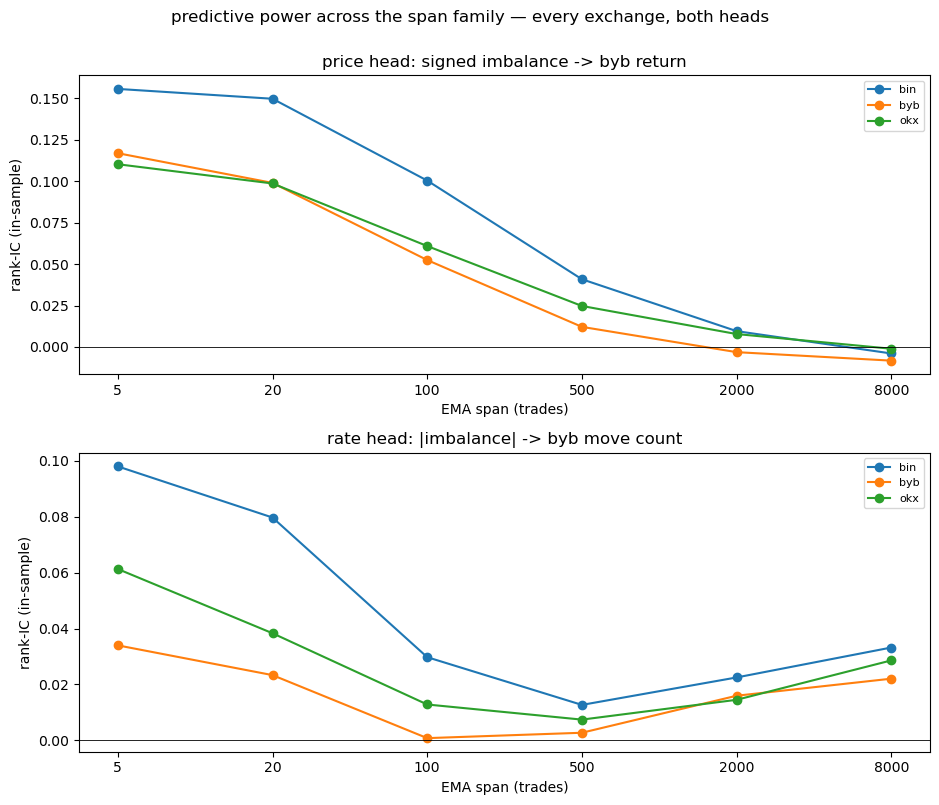

kept features (one per exchange, all fed to the model — none privileged):
  bin:  price head (span=5) power=+0.156   |  rate head (span=5) power=+0.098
  byb:  price head (span=5) power=+0.117   |  rate head (span=5) power=+0.034
  okx:  price head (span=5) power=+0.110   |  rate head (span=5) power=+0.061


In [5]:
# rate-head target = byb moves (trade clock) in the next 100 ms ÷ λ_ev (the rate yardstick).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual" (λ_ev is moves/sec over 100 ms, so this carries units of seconds; the constant horizon factor drops out of the rank correlation)

# Sweep the span family for EVERY exchange, BOTH heads, treating exchanges symmetrically (no assumed leader).
feat_cache = {(ex, N): flow_imbalance(ex, N) for ex in EXCHANGES for N in SPANS}
price_grid = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}   # signed feature -> byb's signed return
rate_grid  = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}   # |feature|      -> byb's move count
for ex in EXCHANGES:
    for j, N in enumerate(SPANS):
        d = feat_cache[(ex, N)]
        price_grid[ex][j] = spearmanr(d, target).statistic               # predictive power for the price head
        rate_grid[ex][j]  = spearmanr(np.abs(d), rate_target).statistic  # rate head — |feature|→count is a univariate DIAGNOSTIC; the model is fed signed d

fig, axes = plt.subplots(2, 1, figsize=(9.5, 8.0))
for row, (grids, head) in enumerate([(price_grid, "price head: signed imbalance -> byb return"),
                                     (rate_grid,  "rate head: |imbalance| -> byb move count")]):
    ax = axes[row]
    for ex in EXCHANGES:
        ax.plot(range(len(SPANS)), grids[ex], "o-", label=ex)
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS)
    ax.set_xlabel("EMA span (trades)"); ax.set_ylabel("rank-IC (in-sample)")
    ax.axhline(0, color="k", lw=0.6); ax.set_title(head); ax.legend(fontsize=8)
fig.suptitle("predictive power across the span family — every exchange, both heads", y=1.00)
fig.tight_layout(); plt.show()

# We do NOT pick an exchange. Every exchange's feature is kept; we only pick the best span PER head PER exchange
# (in-sample), then re-score OUT-OF-SAMPLE in the §5 gates below — that is the number that counts.
def best_span(grid): return int(np.nanargmax(grid))
price_member = {ex: best_span(price_grid[ex]) for ex in EXCHANGES}
rate_member  = {ex: best_span(rate_grid[ex])  for ex in EXCHANGES}
print("kept features (one per exchange, all fed to the model — none privileged):")
for ex in EXCHANGES:
    pj, rj = price_member[ex], rate_member[ex]
    print(f"  {ex}:  price head (span={SPANS[pj]}) power={price_grid[ex][pj]:+.3f}"
          f"   |  rate head (span={SPANS[rj]}) power={rate_grid[ex][rj]:+.3f}")

**Reading the heat-maps.** The **price head** (top) is where this feature lives: the signed
imbalance correlates positively with byb's next return — buy pressure precedes an up-tick — and
the curve picks out a best span per exchange. On this block the best span is the **shortest (N=5)
for every venue**, and the IC falls monotonically as the span lengthens — flow autocorrelation is
strongest in the freshest trades and washes out by the long spans (N≥2000 is ≈0 or negative).
Here **bin leads the price head** (+0.156 in-sample at N=5) ahead of byb's own flow (+0.117) and
okx (+0.110) — bin's sub-ms-fresh trade feed gives the cleanest read; byb and okx still carry the
cross-venue/own-flow signal. The **rate head** (bottom) is a weaker, diagnostic readout (bin +0.098,
okx +0.061, byb +0.034 at N=5): a large |imbalance| tends to accompany busier moving, but direction
is the feature's real job. We keep every exchange and let the model weight whoever is leading.

> But the IC-max pick is only **half** the answer — a second span might add signal the first
> doesn't. The next cell re-scores the family against the chosen span and lets the walk-forward
> joint-vs-solo OOS IC decide whether a second lookback is worth keeping.

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  bin: best alt span N=20 partial-IC|chosen +0.044;  OOS joint +0.149 vs solo +0.148 (Δ+0.002)  ->  one span suffices (no OOS gain)


  byb: best alt span N=500 partial-IC|chosen -0.018;  OOS joint +0.104 vs solo +0.111 (Δ-0.007)  ->  one span suffices (no OOS gain)


  okx: best alt span N=20 partial-IC|chosen +0.015;  OOS joint +0.101 vs solo +0.104 (Δ-0.003)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  bin: best alt span N=8000 partial-IC|chosen +0.033;  OOS joint +0.081 vs solo +0.096 (Δ-0.015)  ->  one span suffices (no OOS gain)


  byb: best alt span N=8000 partial-IC|chosen +0.022;  OOS joint +0.030 vs solo +0.036 (Δ-0.006)  ->  one span suffices (no OOS gain)


  okx: best alt span N=8000 partial-IC|chosen +0.029;  OOS joint +0.049 vs solo +0.062 (Δ-0.012)  ->  one span suffices (no OOS gain)


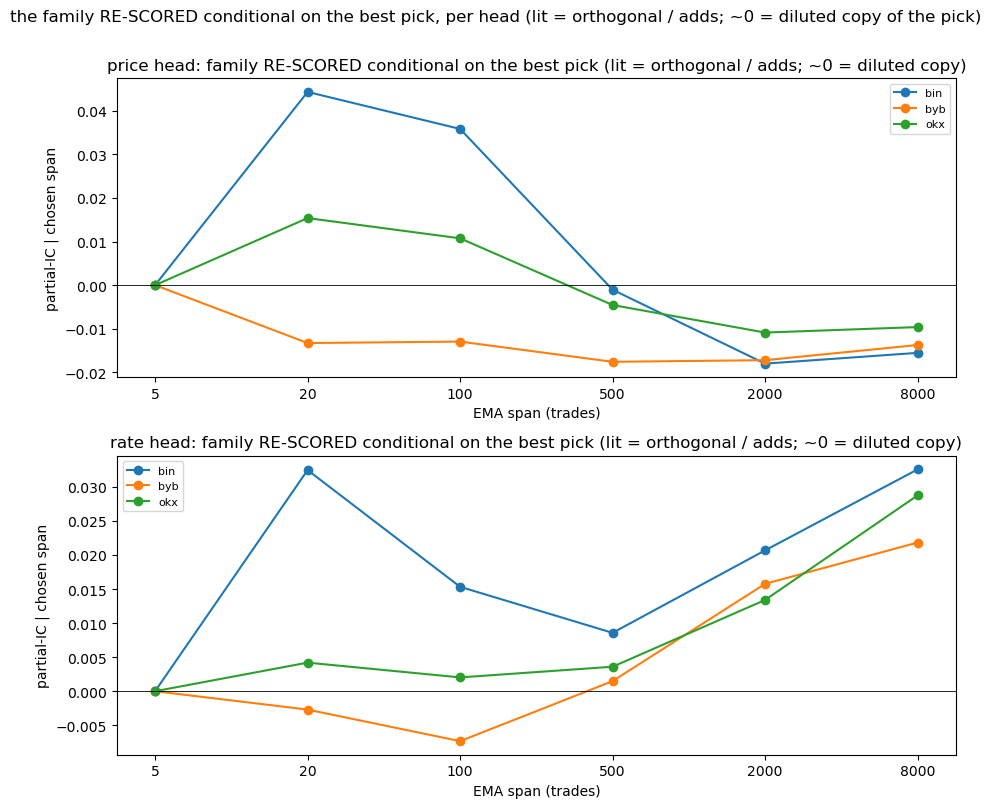

In [6]:
# === Does a SECOND time-scale ADD over the pick? — the sweep RE-SCORED conditional on the best span, PER HEAD ===
# Selection lives here in §6. We picked the best span per head by IC; now re-score the WHOLE span family as
# partial-IC(span | chosen) -- each span's IC against the head's target, CONTROLLING for the span we picked (the
# same partial-IC tool the echo-netting cell uses; control = the chosen span, not the trailing move).
# A span still LIT adds signal ORTHOGONAL to the pick; a span that COLLAPSES to ~0 is a diluted copy. The sweep
# is in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a span to its scored feature, tgt is the head's target, member is the in-sample pick index.
HEADS = [("price head", lambda ex, N: flow_imbalance(ex, N),         target,      price_member),
         ("rate head",  lambda ex, N: np.abs(flow_imbalance(ex, N)), rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), 1, figsize=(9.5, 4.0 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    ax = axes[row][0]
    for ex in EXCHANGES:
        cj = member[ex]; chosen = feat(ex, SPANS[cj])               # the in-sample pick for this head/venue
        cond = np.full(len(SPANS), np.nan)                          # partial-IC(span | chosen) across the 1-D span family
        for j, N in enumerate(SPANS):
            cond[j] = 0.0 if j == cj else _pic(feat(ex, N), tgt, chosen)
        ax.plot(range(len(SPANS)), cond, "o-", label=ex)
        bj = int(np.nanargmax(np.abs(cond)))                        # the most-orthogonal alternative span (in-sample screen)
        f1, f2 = chosen, feat(ex, SPANS[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)        # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                         # the OOS joint gain DECIDES
        second[(head, ex)] = bj if keep else None
        print(f"  {ex}: best alt span N={SPANS[bj]} partial-IC|chosen {cond[bj]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS); ax.set_xlabel("EMA span (trades)")
    ax.set_ylabel("partial-IC | chosen span"); ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{head}: family RE-SCORED conditional on the best pick (lit = orthogonal / adds; ~0 = diluted copy)")
    ax.legend(fontsize=8)
fig.suptitle("the family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC sweep picks the best span per head; a second span is only
worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole family conditional on
the chosen pick** — each span's IC recomputed as `partial-IC(span | chosen)`: its predictive power against the
head's target **controlling for the span we already picked** (the same partial-IC tool the echo-netting cell
uses; control = the chosen span). A span that stays **lit** is **orthogonal** — it adds new signal — while
a span that **collapses to ≈ 0** is a diluted copy of the pick. Because that sweep is **in-sample**, the
keep/drop **decision** is the overfitting-resistant **walk-forward joint-vs-solo** IC
(`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second span only when the out-of-sample gain clears the ~0.01
floor. We run it for **both heads** (price → signed feature vs the σ-return target; rate → |feature| vs the count
target). On this block both find the second span a diluted copy (OOS gain ≈ 0), so one span per head suffices.

**Now the gates** — and they are **two independent tests**, not one. Every *marginal* number is the
**walk-forward** mean (causal, purged); the one exception is the control-standalone **stratified** IC, which is
in-sample decoupled (its out-of-sample confirmation comes from the multi-block harness in `tools/oss`).

One caveat for **both heads**: the span is chosen by the in-sample IC sweep *above* over the **whole** block,
so the walk-forward IC below is **post-selection and provisional** — mildly optimistic, since the test folds
also informed the span pick. Held-out span selection is deferred to the multi-block `tools/oss` harness; here
the choice is among a small 6-span family of near-identical neighbours, so the selection bias is expected to
be small (we don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`** (the rate head
receives the *signed* feature and can learn its magnitude, so a magnitude that tracks the regime would leak
into it), two leak modes against **both regime coordinates** (vol *and* rate level): **tracking** —
`|IC(·, level)|` ≈ 0 (the monotone test, want **< ~0.05** for the signed feature, **< ~0.1** for the
magnitude), and **dispersion** — the spread of its per-decile *means* (want **< ~0.1**), which catches a
*non-monotone* leak the monotone IC misses. The vol/rate level is only the regime *coordinate* here (what we
bucket/correlate against), **never** a control. Fail any one of them = a level in disguise, not a feature.

**Gate B — predictive signal**: does it predict? Because *a control can itself be a valid feature*,
"signal **over** the controls" only makes sense for a feature that **isn't** a control. `flow_imbalance` is
an order-flow **alpha** (not a regime descriptor), so Gate B is its **marginal** rank-IC over the
regime-invariant controls (the momenta — **never** the raw levels), all exchanges together and each on its
own, want ≳ 0.01. **Mechanical-coupling guard:** a *control ratio* dividing by the scored target's yardstick
would inflate the IC arithmetically, fixed by stratifying within that yardstick (`STRAT_VAR`). This feature is
a bounded `E/W` ratio that divides by **neither** `σ_ev` nor `λ_ev` — it shares no denominator with either
target — so `STRAT_VAR = None`. The signed-feature coupling rows below confirm σ_ev isn't manufacturing the
IC. *Regime-stable* (companion): is Gate B still positive **within** calm, mid, and wild vol — not a
one-regime artefact?

In [7]:
# Gates on the set of per-exchange features — symmetric; KEEP ALL exchanges. Marginal value is checked
# JOINTLY (do the exchanges together add over the controls?) and per-exchange (does each contribute?), never by picking one.
# GATE B — predictive signal: MARGINAL rank-IC over the base momenta (a lead test), for an alpha. GATE A — regime
# invariance, run PER EXCHANGE (a property of the output distribution, which differs by venue — bin is sub-ms fresh,
# byb/okx stale). All primitives come from boba.research.gates via the §5 wrappers (base / FEATURE_KIND / STRAT_VAR / vol_regime bound there).
disloc = {ex: flow_imbalance(ex, SPANS[price_member[ex]]) for ex in EXCHANGES}   # the chosen price-head feature per exchange
joint = signal_ic(list(disloc.values()), own=False)                              # all venues together — marginal over the controls
strat = signal_ic_by_regime(list(disloc.values()), own=False)                    # the calm/mid/wild companion
pci = wf_marginal_ci(list(disloc.values()), target)                              # per-fold spread + block-bootstrap 90% CI for the headline marginal
print(f"joint Gate B marginal {joint:.3f}  |  per-fold {pci['per_fold']} (positive in {pci['pos']}/{pci['nf']})  |  block-bootstrap 90% CI [{pci['ci'][0]}, {pci['ci'][1]}]  (block ~{pci['block_len']} anchors ~{pci['block_s']}s)")
rep = disloc[EXCHANGES[0]]                                                        # representative leg — for the momenta-overlap sanity print only (Gate A runs PER EXCHANGE below)
# LOW-1 sanity: an "alpha" must NOT be a hidden regime descriptor -> its overlap with the momenta is small.
print(f"FEATURE_KIND={FEATURE_KIND!r} | feature vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (large for an 'alpha' => it's really a control)")
gate_rows = [dict(gate="B · signal", detail="all exchanges together — marginal over the invariant controls", value=joint)]
gate_rows += [dict(gate="B · signal", detail=f"{ex} alone — marginal over the controls",
                   value=signal_ic([disloc[ex]], own=False)) for ex in EXCHANGES]
# H1 shared-σ_ev coupling check: the σ_ev price target divides by σ_ev; the SIGNED feature does NOT, so the
# standalone IC WITHIN σ_ev strata ≈ the unstratified standalone IC -> σ_ev isn't manufacturing the rank-IC.
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed feature standalone IC, unstratified", value=round(ic(disloc[ex], target), 3)) for ex in EXCHANGES]
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — signed standalone IC WITHIN σ_ev strata (≈ unstratified => σ_ev not manufacturing it)", value=round(stratified_ic(disloc[ex], target, sigma_at_anchor), 3)) for ex in EXCHANGES]
for ex in EXCHANGES:                                   # GATE A PER EXCHANGE (worst coordinate per check) — the output distribution differs by venue
    a = gate_a(disloc[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable", detail=f"signal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(30); pl.Config.set_fmt_str_lengths(60)
pl.DataFrame(gate_rows)

joint Gate B marginal 0.158  |  per-fold [0.157, 0.168, 0.13, 0.145, 0.192] (positive in 5/5)  |  block-bootstrap 90% CI [0.154, 0.164]  (block ~2000 anchors ~100.0s)


FEATURE_KIND='alpha' | feature vs momenta |IC|: rate 0.015 vol 0.019  (large for an 'alpha' => it's really a control)


gate,detail,value
str,str,f64
"""B · signal""","""all exchanges together — marginal over the invariant control…",0.158
"""B · signal""","""bin alone — marginal over the controls""",0.138
"""B · signal""","""byb alone — marginal over the controls""",0.1
"""B · signal""","""okx alone — marginal over the controls""",0.094
"""B · coupling""","""bin — signed feature standalone IC, unstratified""",0.156
"""B · coupling""","""byb — signed feature standalone IC, unstratified""",0.117
"""B · coupling""","""okx — signed feature standalone IC, unstratified""",0.11
"""B · coupling""","""bin — signed standalone IC WITHIN σ_ev strata (≈ unstratifie…",0.155
"""B · coupling""","""byb — signed standalone IC WITHIN σ_ev strata (≈ unstratifie…",0.117


**Conclusion (price head).** Read the gate numbers off the table and printout above — this cell now *computes*
them rather than asserting them. **Gate B**: the joint marginal walk-forward rank-IC over the controls is the
headline number (with its per-fold spread and block-bootstrap 90% CI); each exchange's standalone marginal is
listed beneath it, and the **coupling** rows show the signed standalone IC barely moves when scored *within*
σ_ev strata — so the shared σ_ev isn't manufacturing the IC (as expected for a signed numerator). **Gate A**,
run **per exchange** (a distribution property — venues differ in feed freshness), reports scale / signed-track /
magnitude-track / dispersion against the vol & rate coordinates; a usable feature clears the ~3 / ~0.05 / ~0.1 /
~0.1 bars on every venue. The **companion** shows the marginal gain across calm / mid / wild vol — positive in
all three = regime-stable, not a one-regime artefact. The §10 verdict quotes these printed numbers verbatim.
(The rate head is gated separately just below — its verdict is read off the rate-head gate table, not inherited
from these price-head gates.)

**Now the rate head — its own gates, against the count target.** The block above gated the *price-span*
feature against the σ_ev **price** target. The rate head is fed a **different-span** feature (the
`rate_member` pick) and predicts the **count** target, so its verdict is **not** inherited from the price
gates — it gets the same two-gate battery here.

The rate head's signal lives in the **magnitude**: `|feature| → count` is the §6 diagnostic, and the model is
fed the **signed** feature and recovers `|·|` itself (a nonlinear head can). So **Gate B scores `|feature|`** —
a *linear* score on the signed feature would read ≈ 0 precisely because the count relationship is symmetric, so
`|feature|` is the honest proxy for what the nonlinear rate head extracts. **Coupling guard:** the magnitude
path has no sign to decouple it, and `|feature|` and `count/λ_ev ∝ 1/λ_ev` could share the byb-activity regime
— so we add a **within-λ_ev stratified** line per exchange to confirm the marginal isn't a `1/λ_ev` artefact.
**Gate A** is re-run **per exchange** on the rate-span feature (a distribution property — it differs by venue
*and* by span).

In [8]:
# === RATE-HEAD GATES ===
# The price-head gates above ran the price-SPAN feature against the σ_ev price target. The rate head is fed a
# DIFFERENT-span feature (the rate_member pick) and predicts the COUNT target, so its verdict can't be inherited —
# it gets the SAME two-gate battery here, against the count target. Gate B scores |feature| (the magnitude is the
# rate head's signal); a within-λ_ev stratified line confirms the marginal is not a 1/λ_ev artefact; Gate A re-runs PER EXCHANGE.
disloc_rate = {ex: flow_imbalance(ex, SPANS[rate_member[ex]]) for ex in EXCHANGES}
mag_rate    = {ex: np.abs(disloc_rate[ex]) for ex in EXCHANGES}

joint_rate  = signal_ic(list(mag_rate.values()), own=False, tgt=rate_target)            # |feature|->count, marginal over the controls, all venues together
strat_rate  = signal_ic_by_regime(list(mag_rate.values()), own=False, tgt=rate_target)  # the calm/mid/wild companion
rci = wf_marginal_ci(list(mag_rate.values()), rate_target)                              # per-fold spread + block-bootstrap CI for the rate-head headline marginal
print(f"joint Gate B (rate) marginal {joint_rate:.3f}  |  per-fold {rci['per_fold']} (positive in {rci['pos']}/{rci['nf']})  |  block-bootstrap 90% CI [{rci['ci'][0]}, {rci['ci'][1]}]  (block ~{rci['block_len']} anchors ~{rci['block_s']}s)")
# gate_a (worst-coordinate Gate A, used for both heads) is defined in the §5 wrappers.
rate_rows  = [dict(gate="B · signal (rate)", detail="all exchanges together — marginal |feature|->count over the controls; want >~ 0.01", value=joint_rate)]
rate_rows += [dict(gate="B · signal (rate)", detail=f"{ex} alone — marginal |feature|->count over the controls",
                   value=signal_ic([mag_rate[ex]], own=False, tgt=rate_target)) for ex in EXCHANGES]
rate_rows += [dict(gate="B · coupling (rate)", detail=f"{ex} — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev artefact)",
                   value=round(stratified_ic(mag_rate[ex], rate_target, lam_at_anchor), 3)) for ex in EXCHANGES]
for ex in EXCHANGES:
    a = gate_a(disloc_rate[ex])
    rate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — the rate head sees |feature|, worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
rate_rows += [dict(gate="regime-stable (rate)", detail=f"|feature|->count within {nm}-vol (companion: stay positive)", value=strat_rate.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(30); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(rate_rows)

joint Gate B (rate) marginal 0.034  |  per-fold [0.027, 0.038, 0.036, 0.033, 0.036] (positive in 5/5)  |  block-bootstrap 90% CI [0.031, 0.037]  (block ~9479 anchors ~474.0s)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""all exchanges together — marginal |feature|->count over the controls; …",0.034
"""B · signal (rate)""","""bin alone — marginal |feature|->count over the controls""",0.026
"""B · signal (rate)""","""byb alone — marginal |feature|->count over the controls""",0.003
"""B · signal (rate)""","""okx alone — marginal |feature|->count over the controls""",0.01
"""B · coupling (rate)""","""bin — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.094
"""B · coupling (rate)""","""byb — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.039
"""B · coupling (rate)""","""okx — |feature|->count WITHIN λ_ev strata (stays +ve => not a 1/λ_ev a…",0.064
"""A · regime-inv (bin)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",1.03
"""A · regime-inv (bin)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want <…",0.017


**Conclusion (rate head).** The rate-span feature gets its **own** two-gate battery against the **count**
target — its verdict is *earned*, not inherited from the price gates. **Gate B** scores `|feature| → count`
jointly and per exchange (with the per-fold spread and CI); the **within-λ_ev** coupling rows confirm the
marginal isn't a `1/λ_ev` artefact. **Gate A** re-runs per exchange on the rate-span feature. The companion
checks the gain holds across calm / mid / wild vol. Quote these printed numbers — not the price-head gates —
when the §10 verdict speaks for the rate head.

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor−100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

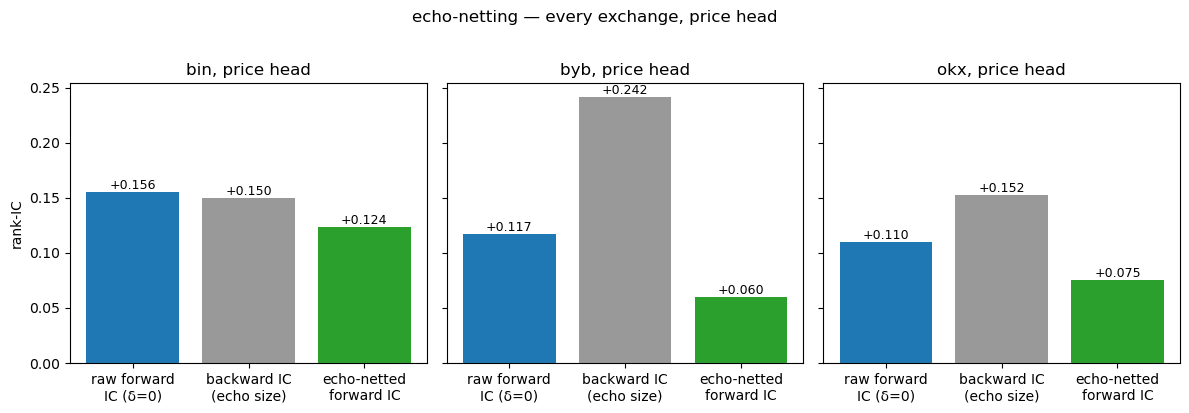

bin:  raw forward IC +0.156;  backward (echo) IC +0.150;  echo-netted forward IC +0.124  (raw->netted shortfall is echo)
byb:  raw forward IC +0.117;  backward (echo) IC +0.242;  echo-netted forward IC +0.060  (raw->netted shortfall is echo)
okx:  raw forward IC +0.110;  backward (echo) IC +0.152;  echo-netted forward IC +0.075  (raw->netted shortfall is echo)


In [9]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
# Run it for EVERY exchange — each venue carries its own echo (its own flow vs byb's contemporaneous move).
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
echo = {}                                                 # per-exchange: (raw forward IC, backward/echo IC, echo-netted forward IC)
for ex in EXCHANGES:
    signed = flow_imbalance(ex, SPANS[price_member[ex]])  # the chosen price-head feature for this exchange
    echo[ex] = (_ic(signed, _fwd0), _ic(signed, _trail), _partial_ic(signed, _fwd0, _trail))

fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(4.0 * len(EXCHANGES), 4.0), sharey=True)
labels = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
for ax, ex in zip(np.atleast_1d(axes), EXCHANGES):
    vals = list(echo[ex])
    bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
    ax.axhline(0, color="0.7", lw=0.8); ax.set_title(f"{ex}, price head")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
np.atleast_1d(axes)[0].set_ylabel("rank-IC")
fig.suptitle("echo-netting — every exchange, price head", y=1.02); fig.tight_layout(); plt.show()
for ex in EXCHANGES:
    raw_ic, back_ic, echo_net = echo[ex]
    print(f"{ex}:  raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor−100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100–160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by
the feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for strong-sell / balanced / strong-buy imbalance — it
  should tilt down when sellers dominate and up when buyers do;
- **rate head:** how the number of upcoming moves grows as the imbalance's *magnitude* grows.

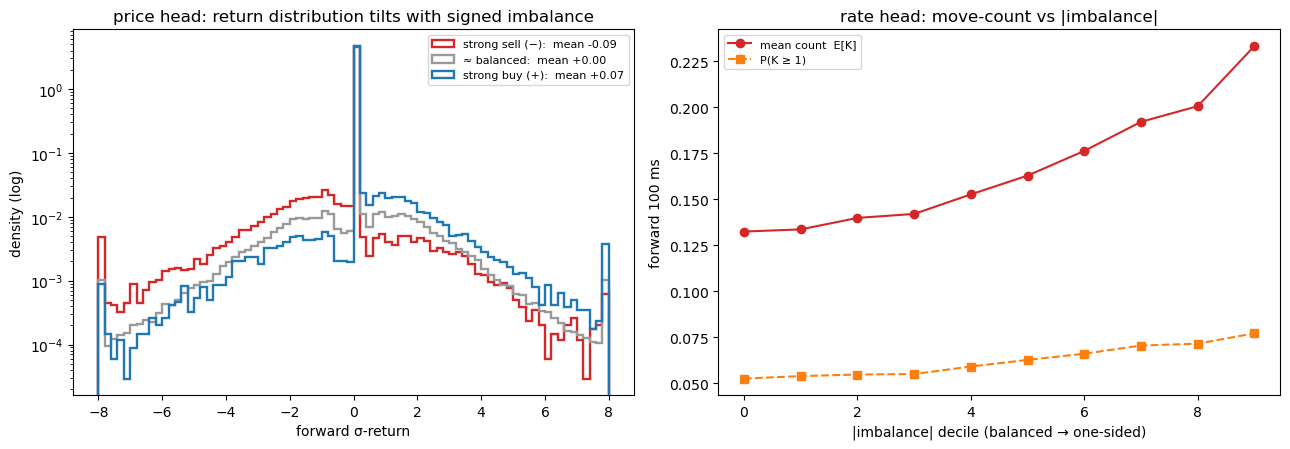

In [10]:
rep_ex = "byb"                                                                  # byb's own flow shown to illustrate the shape; the model uses every exchange
signed = feat_cache[(rep_ex, SPANS[price_member[rep_ex]])]
absmag = np.abs(feat_cache[(rep_ex, SPANS[rate_member[rep_ex]])])              # the RATE-head span pick of the same feature
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-imbalance buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong sell (−)", signed <= lo, "C3"), ("≈ balanced", (signed > lo) & (signed < hi), "0.6"),
          ("strong buy (+)", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axA.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: return distribution tilts with signed imbalance"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |imbalance|
# raw fwd_count is shown here only for intuition; the rate head's actual target is rate_target = fwd_count / λ_ev (count ÷ λ_ev)
dec = np.digitize(absmag, np.nanpercentile(absmag, np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|imbalance| decile (balanced → one-sided)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count vs |imbalance|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the way the two heads need —
not just a single summary number (shown here for byb's own flow; the model uses every venue).
**Price head (left):** the forward-return distribution shifts bodily with the *signed* imbalance — a
negative mean for strong-sell flow, positive for strong-buy, with the balanced group between (read the
group means in the legend) — so the sign genuinely carries direction (the feature's main job), consistent
with byb's positive signed price-head IC (+0.117) in §6. **Rate head (right):** the diagnostic readout of
mean move-count `E[K]` and `P(K ≥ 1)` climbs with |imbalance| — a secondary, intensity-flavoured signal
the model can still learn from the signed feature (byb's rate leg is the weakest, as §6's gates showed).
Both heads have something to learn here, in the directions §1 predicted.

## 8. Input shaping for the network

This is a *different* step from §2. There the question was whether to divide out volatility (the
"regime division") — and for this bounded ratio the answer was *no*. Here we reshape the feature for
the neural network's input — roughly centred, unit-scale, no wild outliers.

Pick the **lightest** transform that does the job. Plot the feature (left) and compare a few
candidates by how close to a clean bell curve they make it (right — points on the diagonal are
perfectly normal). The imbalance is already bounded in `[−1, 1]`, so it has **no** fat tails to
clip — the question is mostly whether to center/scale it or spread out a possible pile-up near 0.

feature: range=[-1.000, 1.000]  std=0.920  skew=-0.15  excess_kurt=-1.87  (0 = normal)
  z-score            excess_kurt= -1.87   max|·|=1.2
  robust z           excess_kurt= -1.87   max|·|=1.7
  arcsinh(robust)    excess_kurt= -1.89   max|·|=1.3
  rank-Gaussian      excess_kurt= -0.39   max|·|=2.2


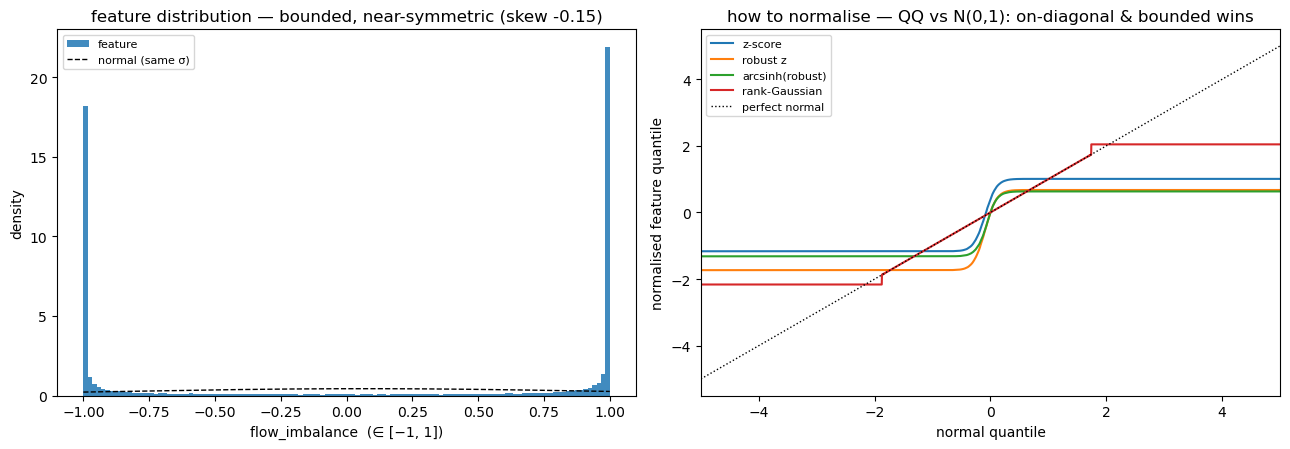

In [11]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = "byb"
f = feat_cache[(rep_ex, SPANS[price_member[rep_ex]])]; f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-12; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-12),
        "robust z": rz,
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: range=[{f.min():.3f}, {f.max():.3f}]  std={f.std():.3f}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.2f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.2f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature")
xg = np.linspace(f.min(), f.max(), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_xlabel("flow_imbalance  (∈ [−1, 1])"); axA.set_ylabel("density")
axA.set_title(f"feature distribution — bounded, near-symmetric (skew {skew(f):+.2f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles it. The imbalance is a bounded `[−1, 1]` ratio (range exactly
`[−1.000, 1.000]`, std **0.920**, skew **−0.15** — near-symmetric), so it has **no wild outliers** to tame:
`max|·|` after a plain z-score is just **1.2**. Its excess kurtosis is strongly *negative* (**−1.87**) —
the mass piles toward the bounds ±1 (one-sided flow is common at the short span), a *platykurtic*, not
fat-tailed, shape — which is the harmless direction (no tail to clip). So the **lightest** transform — a plain
z-score (subtract mean, divide by std) — is enough; the heavier maps (arcsinh barely changes it,
rank-Gaussian only lifts excess-kurt to −0.39 by spreading the ±1 piles) would just throw away the meaningful
gradations near the centre. This is the opposite of the template's gap, which needed a clip; a bounded feature
is the easy case.

**Still to run** (same machinery): whether the feature adds over features we already have;
whether the signal is steady day-to-day; and whether it survives out-of-sample across a
market-regime change. (The leak check *inside* volatility buckets is no longer pending —
Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-exchange worth it? (for poolable features)

Unlike the template's gap (a quantity *between* two exchanges), the flow imbalance is a genuine
**per-exchange** number — so the pool / single / per-exchange choice is real here. The answer
depends on the time-scale, so sweep it and compare the three:
- **pooled** — one imbalance over *all* venues' trades on the shared clock;
- **best single** — the single most predictive exchange's imbalance (in-sample pick, scored OOS);
- **per-exchange** — all three fed in together.

We score each by **marginal walk-forward** rank-IC over the controls (against byb's next return), at
a short, a medium, and a long span, to see where keeping the venues separate pays off.

In [12]:
# pooled imbalance: sum signed_qty and qty across ALL venues per clock tick, then the same E/W EMA.
def pooled_imbalance(N):
    a = 2.0 / (N + 1.0)
    e_inj = sum(inject[ex][0] for ex in EXCHANGES); w_inj = sum(inject[ex][1] for ex in EXCHANGES)
    E = lfilter([a], [1.0, -(1.0 - a)], e_inj); W = lfilter([a], [1.0, -(1.0 - a)], w_inj)
    return (E / np.where(W > 0.0, W, np.nan))[tick_at_anchor]

scan = [("short", SPANS[1]), ("medium", SPANS[3]), ("long", SPANS[5])]   # 20 / 500 / 8000 trades
rows = []
for label, N in scan:
    per_ex = [flow_imbalance(ex, N) for ex in EXCHANGES]
    single_ic = {ex: wf_ic(base + [flow_imbalance(ex, N)], target) - wf_ic(base, target) for ex in EXCHANGES}
    best_ex = max(single_ic, key=single_ic.get)
    pooled  = round(wf_ic(base + [pooled_imbalance(N)], target) - wf_ic(base, target), 3)
    single  = round(single_ic[best_ex], 3)
    perex   = round(wf_ic(base + per_ex, target) - wf_ic(base, target), 3)
    rows.append(dict(time_scale=f"{label} (N={N})", pooled=pooled, best_single=f"{single} ({best_ex})", per_exchange=perex))
pl.DataFrame(rows)

time_scale,pooled,best_single,per_exchange
str,f64,str,f64
"""short (N=20)""",0.151,"""0.14 (bin)""",0.149
"""medium (N=500)""",0.035,"""0.039 (bin)""",0.04
"""long (N=8000)""",-0.008,"""-0.004 (okx)""",-0.005


**Conclusion.** Marginal walk-forward rank-IC over the controls for **pooled** vs **best single** vs
**per-exchange**, at a short / medium / long span. On this block:
- **short (N=20):** pooled **0.151**, per-exchange **0.149**, best single **0.140 (bin)** — pooled and
  per-exchange are neck-and-neck and both edge the single venue; at the short span the flow signal is
  strong and broadly shared, so any of the three works (a blurry pool doesn't yet cost much).
- **medium (N=500):** per-exchange **0.040** > best single **0.039 (bin)** > pooled **0.035** — the
  classic middle band where **keeping the venues separate pays off** (pooling starts to blur the structure).
- **long (N=8000):** all three are ≈0 / slightly **negative** (pooled −0.008, single −0.004, per-ex −0.005)
  — the imbalance has decayed to a common drift with no residual edge.

So the per-exchange/pool choice is real and **time-scale-dependent**: pooling is competitive only at the
short span and *loses* in the middle band, where per-exchange is best. Keep **all exchanges** as the safe
default — the extra venues never hurt and capture the rotating lead — and let the model down-weight the
redundant ones at long scales. (For this block per-exchange ≥ pooled at every useful scale, so **per-exchange
is the winner** overall; pooling is never strictly best.)

## 10. The verdict, and what it takes to ship

**Keep it — feed the *signed* imbalance to both heads (each head gated separately in §6), all exchanges,
at the chosen span(s):** on this block it clears every local gate — price-head Gate B **+0.158** joint (5/5
folds, block-bootstrap 90% CI [0.154, 0.164]), rate-head Gate B **+0.034** joint (5/5 folds, CI [0.031,
0.037]), Gate A within bars on every exchange (scale ≤ 1.03, signed-track ≤ 0.025, magnitude-track ≤ 0.05,
dispersion ≤ 0.043 — all ≪ the ~3 / ~0.05 / ~0.1 / ~0.1 bars), and both companions positive across calm/mid/wild.
- **Price head (direction, its main job):** the single E/W imbalance at the best span per exchange — here
  the **shortest span (N=5)** for every venue, where flow autocorrelation is strongest (the IC decays
  monotonically to ≈0 by N≥2000). Buy pressure → byb ticks up; the sign carries the direction. The joint
  Gate-B marginal is **+0.158**; each venue also adds on its own (**bin +0.138, byb +0.100, okx +0.094** over
  the controls), and the signed standalone IC barely moves within σ_ev strata (bin 0.156→0.155, byb/okx
  unchanged), so the shared σ_ev isn't manufacturing it. The companion holds across regimes (calm **+0.150**,
  mid **+0.162**, wild **+0.169**). The §6 conditional partial-IC test finds **no second span adds
  out-of-sample** over the pick (the family is a diluted copy of N=5), so one span per venue suffices.
- **Rate head (intensity, secondary):** the same *signed* feature, at its own span (here also N=5; the
  conditional partial-IC test again finds no second span adds OOS); the rate head recovers the magnitude and
  learns how venues' flows cancel or reinforce. Never feed a pre-computed `|imbalance|` per exchange — that
  destroys the sign and the cross-venue interaction. The rate-span feature was put through its **own** Gate A/B
  battery against the **count** target (the rate-head gate table in §6) and clears it — joint Gate B **+0.034**,
  carried mostly by **bin** on its own (**+0.026**), with okx marginal (**+0.010**) and byb's own rate leg the
  weak one (**+0.003**); the within-λ_ev coupling lines stay positive (bin 0.094, byb 0.039, okx 0.064), so the
  marginal isn't a 1/λ_ev artefact. "Keep it" is therefore *earned* for the rate head too, not inherited.

Feed **every exchange's** signed imbalance in and let the model lean on whichever venue is leading;
don't collapse to one "leader." The feature needs **no** σ-division — it is a bounded `[−1, 1]` ratio
already comparable across regimes. The move-count it (secondarily) predicts is divided by the rate
yardstick `λ_ev` in the target.

**Cite the echo-netted IC, not the raw δ=0 IC.** The headline δ=0 IC over-credits the move already
underway at the anchor. The **echo-netted (partial) forward IC** — the feature's forward-return IC
controlling for the trailing `[anchor−100 ms, anchor]` move — is the honest number to quote. Run per venue
(the echo-netting cell now loops all three), **byb's own imbalance shrinks most** under netting
(**0.117 → 0.060**) — and its **backward IC is by far the largest (+0.242** vs bin +0.150, okx +0.152), confirming
byb's flow is the contemporaneous, already-underway move — while the **foreign** legs keep most of their IC
(**bin 0.156 → 0.124, okx 0.110 → 0.075** — a real cross-venue order-flow lead) and stay clearly positive. A
near-zero netted IC alongside a large backward IC would be the one true non-signal; none of these legs is that.
The foreign venues' freshness lead is **genuine, exploitable edge** (the recording is production timing), not an
artifact to coarsen away. Quote the netted number before shipping any leg on its raw δ=0 IC.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, matching this analysis version — **done,
      §4 is bit-exact on a real block (parity worst max|diff| ≈ 9e-16)**
- [ ] the parity check (§4) and tests, passing
- [ ] the gate results recorded (with any failures justified) — **done, §6 Gate A/B + companion + echo-netting
      all computed and printed on this block; no failures**
- [ ] the chosen heads and time-scales written down, with the yardstick spans
- [ ] the data quirks handled (bad zero-price/zero-qty prints filtered; the venue-specific
      aggressor convention via `io._trade_lifts_ask`; same-timestamp prints summed into one event)